In [4]:
import pandas as pd

# 读取 marker 文件和 synapse CSV 文件
marker_file = r"Z:\SEU-ALLEN\Users\ZhixiYun\data\H01\C3\C3_syn_marker\2919572550.marker"
synapse_file = r"Z:\SEU-ALLEN\Users\ZhixiYun\data\H01\C3\C3_synapse_csv\2919572550.csv"


# 读取 marker 文件，假设格式为: x, y, z
markers = []
with open(marker_file, 'r') as f:
    for line in f:
        # 将每一行按逗号分隔，去掉换行符并存入列表
        markers.append(line.strip().split(','))

# 读取 synapse 文件，假设包含 x, y, z, synapse_type 列
synapse_df = pd.read_csv(synapse_file)

# 将 marker 数据转为 DataFrame，假设每行是 x, y, z 三列，因此需要为 'color' 添加默认值
# 这里给 color 列一个默认值（比如 0）
markers_df = pd.DataFrame(markers, columns=['x', 'y', 'z'])

# 添加一个默认的 'color' 列
markers_df['color'] = 0  # 默认颜色为 0

# 将坐标转换为数值类型
markers_df[['x', 'y', 'z']] = markers_df[['x', 'y', 'z']].apply(pd.to_numeric)
synapse_df[['x', 'y', 'z']] = synapse_df[['x', 'y', 'z']].apply(pd.to_numeric)

# 根据 synapse_type 修改 marker 颜色
for idx, row in synapse_df.iterrows():
    # 找到与 CSV 中坐标匹配的 marker
    condition = (markers_df['x'] == row['x']) & (markers_df['y'] == row['y']) & (markers_df['z'] == row['z'])
    
    if condition.any():
        # 根据 synapse_type 修改颜色
        if row['synapse_type'] == 'pre':
            markers_df.loc[condition, 'color'] = 5  # 5号色
        elif row['synapse_type'] == 'post':
            markers_df.loc[condition, 'color'] = 4  # 4号色

# 保存更新后的 marker 文件
markers_df.to_csv('2919572550_updated_marker.marker', index=False, header=False)

# 打印修改后的结果
print("Updated markers:")
print(markers_df)



Updated markers:
              x          y         z  color
0           0.0        1.0       2.0      0
1     2518256.0   775328.0  152097.0      4
2     2184864.0   868560.0  143946.0      4
3     2498472.0   967032.0  127413.0      4
4     2250064.0   741208.0   93687.0      4
...         ...        ...       ...    ...
8331  2593512.0  1063488.0  160017.0      4
8332  2251976.0  1086840.0  127413.0      4
8333  2531912.0   851688.0   93918.0      4
8334  2188832.0   967296.0  153120.0      4
8335  2430544.0   858848.0  149391.0      4

[8336 rows x 4 columns]


In [27]:
import pandas as pd

# 读取 marker 文件和 synapse CSV 文件
marker_file = r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132.marker"
synapse_file = r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132.csv"

# 读取 marker 文件，假设格式为: x, y, z
markers = []
with open(marker_file, 'r') as f:
    for line in f:
        # 将每一行按逗号分隔，去掉换行符并存入列表
        markers.append(line.strip().split(','))

# 读取 synapse 文件，假设包含 x, y, z, synapse_type 列
synapse_df = pd.read_csv(synapse_file)

# 将 marker 数据转为 DataFrame，假设每行是 x, y, z 三列，因此需要为 'color' 添加默认值
markers_df = pd.DataFrame(markers, columns=['x', 'y', 'z'])

# 添加一个默认的 'color' 列
markers_df['color'] = 0  # 默认颜色为 0

# 将坐标转换为数值类型
markers_df[['x', 'y', 'z']] = markers_df[['x', 'y', 'z']].apply(pd.to_numeric)
synapse_df[['x', 'y', 'z']] = synapse_df[['x', 'y', 'z']].apply(pd.to_numeric)

# 根据 synapse_type 修改 marker 颜色
for idx, row in synapse_df.iterrows():
    # 找到与 CSV 中坐标匹配的 marker
    condition = (markers_df['x'] == row['x']) & (markers_df['y'] == row['y']) & (markers_df['z'] == row['z'])
    
    if condition.any():
        # 根据 synapse_type 修改颜色
        if row['synapse_type'] == 'pre':
            markers_df.loc[condition, 'color'] = 5  # 5号色
        elif row['synapse_type'] == 'post':
            markers_df.loc[condition, 'color'] = 4  # 4号色

# 只保留 synapse_type 为 'pre' 的 marker
pre_markers_df = markers_df[markers_df['color'] == 5]

# 保存只包含 pre 的 marker 文件
pre_markers_df.to_csv(r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132_pre.marker", index=False, header=False)

# 打印修改后的结果
print("Updated markers with only 'pre' synapse type:")
print(pre_markers_df)


Updated markers with only 'pre' synapse type:
              x          y         z  color
3     2881512.0   865600.0  110583.0      5
18    2966184.0  1026328.0  104346.0      5
290   3029440.0   982960.0   73128.0      5
364   2892288.0   898016.0  151899.0      5
370   3002896.0  1070680.0   93291.0      5
...         ...        ...       ...    ...
7820  2897424.0  1066312.0   91542.0      5
8090  2981744.0  1080792.0  129096.0      5
8140  2892224.0   897896.0  151899.0      5
8211  2914464.0  1078504.0  133254.0      5
8428  2940344.0  1000120.0   76494.0      5

[68 rows x 4 columns]


In [14]:
import pandas as pd
import numpy as np

# 读取 SWC 文件
def read_swc(swc_file):
    # 读取 SWC 文件并转换为 DataFrame
    swc_data = pd.read_csv(swc_file, header=None, sep=' ', names=['ID', 'Type', 'X', 'Y', 'Z', 'Radius', 'Parent'], comment='#')
    return swc_data

# 读取 Synapse 信息文件
def read_synapse(synapse_file):
    synapse_data = pd.read_csv(synapse_file)

    # 打印列名，检查是否存在 x, y, z
    print("Synapse Data Columns:", synapse_data.columns)

    # 清理列名，去掉可能的空格
    synapse_data.columns = synapse_data.columns.str.strip()

    # 检查是否包含 x, y, z 列
    if not all(col in synapse_data.columns for col in ['x', 'y', 'z']):
        raise ValueError("Synapse CSV does not contain the expected 'x', 'y', 'z' columns.")

    return synapse_data

# 根据 Synapse 信息更新节点类型
def classify_branch_based_on_synapse(swc_data, synapse_data):
    # 保留原始的胞体节点（Type=1）
    swc_data['Type'] = swc_data['Type'].apply(lambda x: 1 if x == 1 else 0)

    # 提取 synapse_data 中的 pre 和 post 信息
    pre_positions = synapse_data[synapse_data['synapse_type'] == 'pre'][['x', 'y', 'z']]
    post_positions = synapse_data[synapse_data['synapse_type'] == 'post'][['x', 'y', 'z']]

    # 遍历 SWC 数据，比较位置并推测类型
    for idx, row in swc_data.iterrows():
        # 如果是胞体节点，跳过
        if row['Type'] == 1:
            continue
        
        # 获取当前节点的 X, Y, Z 坐标
        node_position = row[['X', 'Y', 'Z']].values

        # 计算当前节点与 pre 和 post 节点的距离
        pre_distances = np.linalg.norm(pre_positions.values - node_position, axis=1)
        post_distances = np.linalg.norm(post_positions.values - node_position, axis=1)

        # 如果当前节点与 pre 节点的距离最小，标记为 pre（轴突）
        if pre_distances.min() < post_distances.min():
            swc_data.at[idx, 'Type'] = 3  # 轴突类型 3
        # 如果当前节点与 post 节点的距离最小，标记为 post（树突）
        elif post_distances.min() < pre_distances.min():
            swc_data.at[idx, 'Type'] = 2  # 树突类型 2
        else:
            swc_data.at[idx, 'Type'] = 4  # 如果既不属于 pre 也不属于 post，默认为顶树突类型 4
    
    return swc_data

# 写入新的 SWC 文件
def write_swc(swc_data, output_file):
    # 将更新后的数据写入新的 SWC 文件，保留原格式的小数点位数
    with open(output_file, 'w') as f:
        for idx, row in swc_data.iterrows():
            f.write(f"{int(row['ID'])} {int(row['Type'])} {row['X']:.6f} {row['Y']:.6f} {row['Z']:.6f} {row['Radius']:.6f} {int(row['Parent'])}\n")

# 示例：从文件读取 SWC 和 Synapse 数据，推测类型，并输出新的 SWC 文件
def main():
    # 输入 SWC 文件路径和 Synapse CSV 文件路径
    swc_file = r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132_sort.swc"  # 替换为实际的 SWC 文件路径
    synapse_file = r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132.csv"  # 替换为实际的 synapse 信息文件路径
    output_file = r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132_11.swc"  # 输出带有类型信息的 SWC 文件路径

    # 读取 SWC 数据
    swc_data = read_swc(swc_file)

    # 读取 Synapse 数据
    synapse_data = read_synapse(synapse_file)

    # 根据 Synapse 信息推测分支类型
    swc_data_with_types = classify_branch_based_on_synapse(swc_data, synapse_data)

    # 写入新的 SWC 文件
    write_swc(swc_data_with_types, output_file)
    print(f"SWC 文件已保存为 {output_file}")

if __name__ == "__main__":
    main()


Synapse Data Columns: Index(['Unnamed: 0', 'x', 'y', 'z', 'synapse_type', 'in_dataset'], dtype='object')
SWC 文件已保存为 D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132_11.swc


In [17]:
import pandas as pd

# 读取 SWC 文件
def read_swc(swc_file):
    # 读取 SWC 文件并转换为 DataFrame
    swc_data = pd.read_csv(swc_file, header=None, sep=' ', names=['ID', 'Type', 'X', 'Y', 'Z', 'Radius', 'Parent'], comment='#')
    return swc_data

# 根据 Parent 字段递归查找子树
def find_subtree(parent_id, swc_data):
    subtree = []
    nodes_to_process = [parent_id]
    while nodes_to_process:
        current_node_id = nodes_to_process.pop()
        subtree.append(current_node_id)
        children = swc_data[swc_data['Parent'] == current_node_id]
        nodes_to_process.extend(children['ID'].tolist())
    return subtree

# 找出所有胞体节点为起始点的分支数量
def count_branches(swc_data):
    # 获取所有胞体节点（Type=1）
    cell_body_nodes = swc_data[swc_data['Type'] == 1]['ID']
    
    # 遍历所有胞体节点，提取其子树
    branches = []
    for cell_body_node in cell_body_nodes:
        # 获取所有一级子节点
        first_level_children = swc_data[swc_data['Parent'] == cell_body_node]['ID']
        
        # 对每个一级子节点进行递归查找，得到所有子树
        for child in first_level_children:
            subtree = find_subtree(child, swc_data)
            branches.append(subtree)
    
    return len(branches), branches

# 示例：从文件读取 SWC 数据并找出分支数量
def main():
    # 输入 SWC 文件路径
    swc_file = r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132_sort.swc"  # 替换为实际的 SWC 文件路径
    
    # 读取 SWC 数据
    swc_data = read_swc(swc_file)

    # 找出从胞体节点出发的分支数量
    num_branches, branches = count_branches(swc_data)

    # 输出分支数量
    print(f"该 SWC 文件包含 {num_branches} 个从胞体节点出发的分支。")
    for i, branch in enumerate(branches, start=1):
        print(f"分支 {i}: {branch}")

if __name__ == "__main__":
    main()


该 SWC 文件包含 3 个从胞体节点出发的分支。
分支 1: [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 55522, 55523, 55524, 55525, 50, 51, 52, 53, 54, 55, 56, 55507, 55508, 55509, 55510, 55511, 55512, 55513, 55514, 55520, 55521, 55515, 55516, 55517, 55518, 55519, 57, 58, 59, 60, 61, 62, 63, 50775, 50776, 50777, 50778, 50779, 50780, 50781, 50782, 50783, 50784, 50785, 50786, 50787, 50788, 50789, 50790, 50791, 50792, 50793, 50794, 50795, 50796, 50797, 50798, 50799, 50800, 50801, 50802, 50803, 50804, 50805, 50806, 50807, 50808, 50809, 50810, 50811, 50812, 50813, 50814, 50815, 50817, 50818, 50819, 50820, 50821, 50822, 50823, 50824, 50825, 50826, 50827, 50828, 50829, 50830, 50831, 50832, 50833, 50834, 55498, 55499, 55500, 55501, 55502, 55503, 55504, 55505, 55506, 50835, 50836, 50837, 50838, 50839, 50840, 50841, 50842, 50843, 50844, 55491, 55492, 55493, 55494, 55495, 55496, 55497, 50845, 50846, 50847, 50848, 50849, 50850, 50851, 50

C:\Users\SEU\AppData\Local\Temp\ipykernel_19948\3703255761.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab10', len(filenames))  # 给每个神经元分配一个颜色


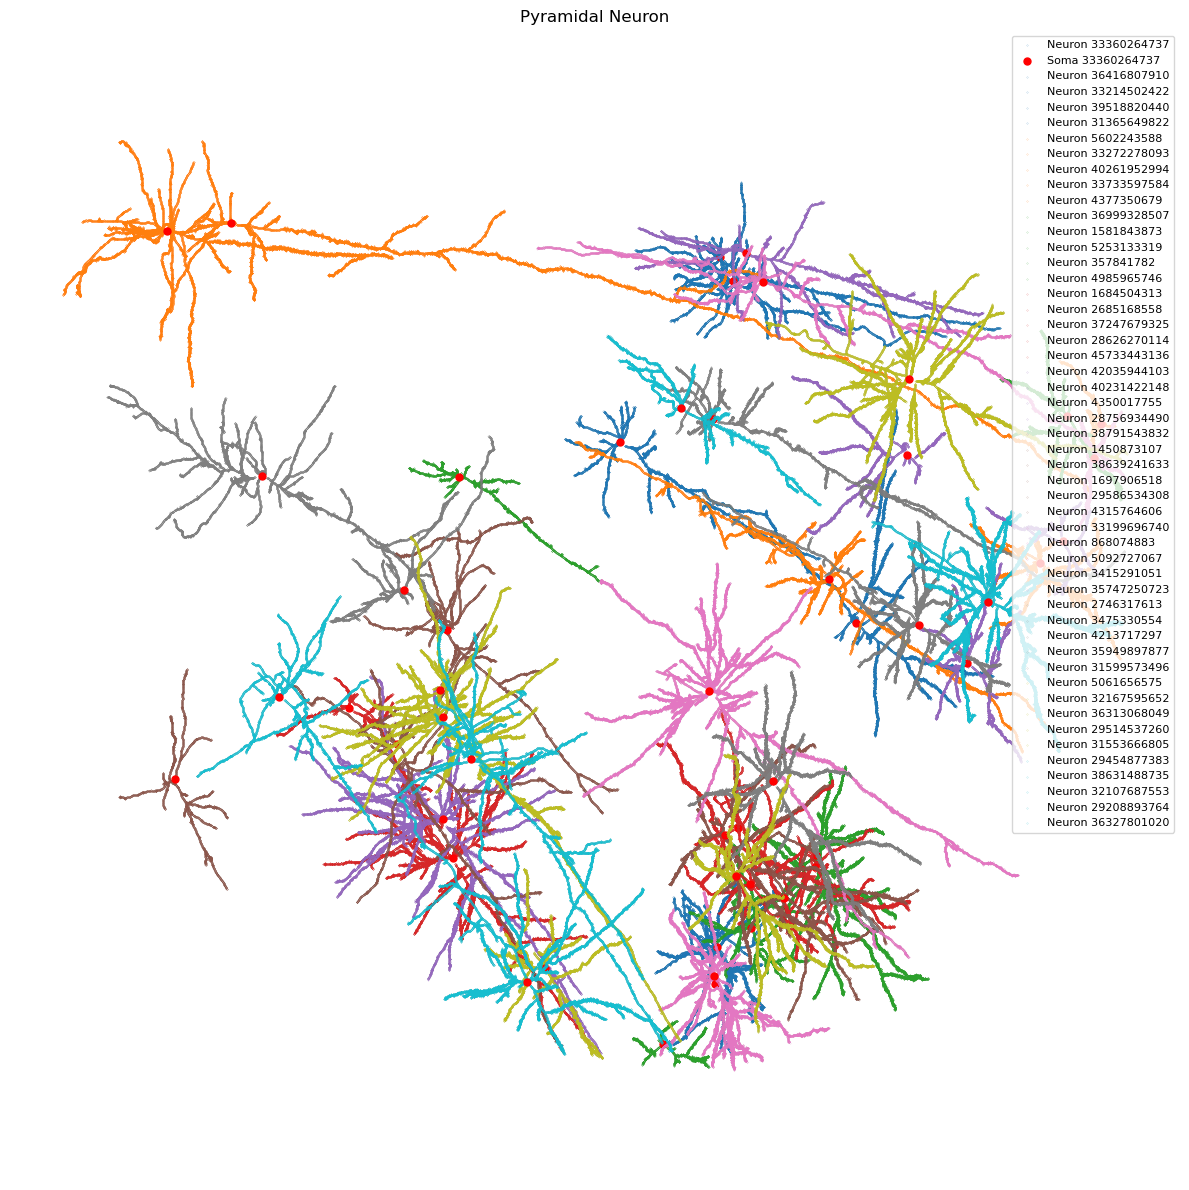

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# 文件路径定义
swc_folder =r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\cell_type_sorted\soma_merge\2radius\pyramidal_neuron"
red_points_file = r"D:\GXQ\cross_em_lm\test_script\reassigned_labels3.csv"
merged_data_file = r'Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\merged_data_98.csv'

# 加载数据
red_points_df = pd.read_csv(red_points_file)
merged_data_df = pd.read_csv(merged_data_file)

# 定义输出文件夹
output_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\cell_type_sorted\soma_merge\combined_plot"
os.makedirs(output_folder, exist_ok=True)

# 筛选 pyramidal neuron 数据
cell_type_data = merged_data_df[merged_data_df['Cell type'] == "pyramidal neuron"][:50]
filenames = cell_type_data['Filename'].astype(str).tolist()
red_points_df['Filename'] = red_points_df['Filename'].astype(str)

# 初始化绘图
plt.figure(figsize=(12, 12))
color_map = plt.cm.get_cmap('tab10', len(filenames))  # 给每个神经元分配一个颜色

for idx, neuron_id in enumerate(filenames):  
    neuron_id_1 = f"{neuron_id}"
    red_point = red_points_df[red_points_df['Filename'] == neuron_id_1]
    if red_point.empty:
        print(f"文件 {neuron_id} 没有找到对应的红点坐标")
        continue

    red_point_x = red_point['Soma_X'].values[0]
    red_point_y = red_point['Soma_Y'].values[0]
    
    # 读取 SWC 文件数据
    swc_fn = f"{neuron_id}_sort.swc"
    swc_path = os.path.join(swc_folder, swc_fn)
    
    if not os.path.exists(swc_path):
        print(f"SWC 文件 {swc_fn} 不存在")
        continue
    
    df_swc = pd.read_csv(swc_path, index_col=None, header=None, skiprows=15, sep=' ')
    
    # 绘制神经元点到同一张图
    plt.scatter(df_swc.iloc[:, 2].values, df_swc.iloc[:, 3].values, color=color_map(idx), s=0.01, label=f"Neuron {neuron_id}")
    plt.scatter(red_point_x, red_point_y, color='red', s=25, marker='o', label=f"Soma {neuron_id}" if idx == 0 else "")

# 设置图形属性
plt.title("Pyramidal Neuron")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.axis('off')

# 保存图片
output_path = os.path.join(output_folder, "pyramidal_neuron_combined.png")
plt.tight_layout()
plt.show()


C:\Users\SEU\AppData\Local\Temp\ipykernel_19948\703013324.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab10', len(filenames))  # 给每个神经元分配一个颜色


SWC 文件 59202062652_sort.swc 不存在
SWC 文件 4001141262_sort.swc 不存在


C:\Users\SEU\AppData\Local\Temp\ipykernel_19948\703013324.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  layer_colors = plt.cm.get_cmap('Set1', len(boundary_df['Layer'].unique()))


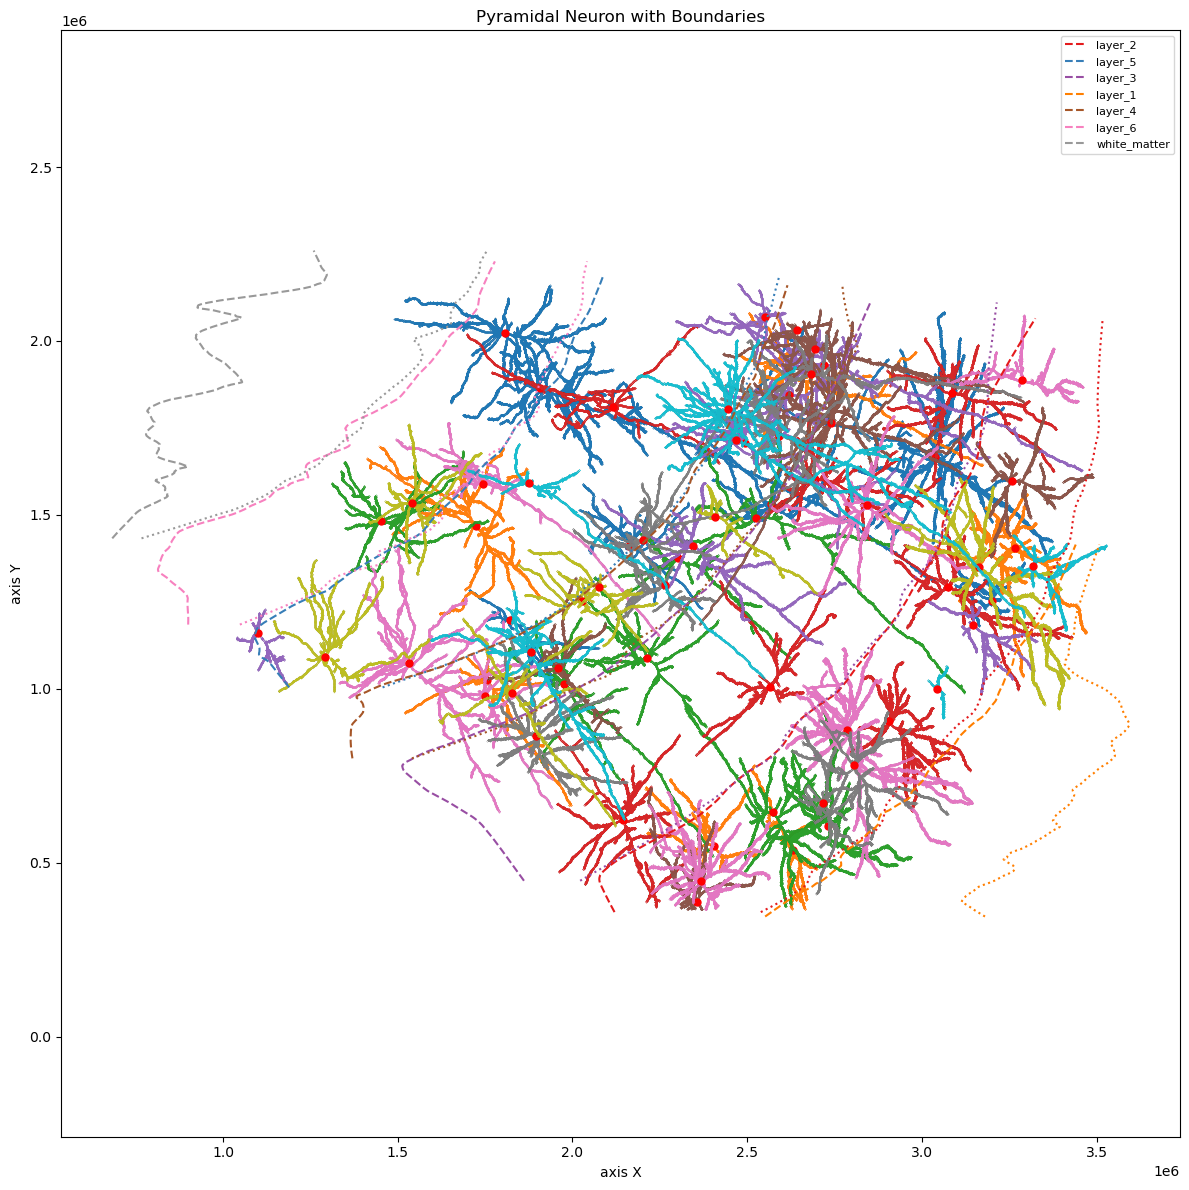

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# 文件路径定义
swc_folder =r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\cell_type_sorted\soma_merge\2radius\pyramidal_neuron"
red_points_file = r"D:\GXQ\cross_em_lm\test_script\reassigned_labels3.csv"
merged_data_file = r'Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\merged_data_98.csv'
boundary_file = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\dbscan_boundaries_nm.csv"

# 加载数据
red_points_df = pd.read_csv(red_points_file)
merged_data_df = pd.read_csv(merged_data_file)
boundary_df = pd.read_csv(boundary_file)

# 定义输出文件夹
output_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\cell_type_sorted\soma_merge\combined_plot"
os.makedirs(output_folder, exist_ok=True)


# 筛选 pyramidal neuron 数据
cell_type_data = merged_data_df[merged_data_df['Cell type'] == "pyramidal neuron"][180:250]
filenames = cell_type_data['Filename'].astype(str).tolist()
red_points_df['Filename'] = red_points_df['Filename'].astype(str)

# 初始化绘图
plt.figure(figsize=(12, 12))
color_map = plt.cm.get_cmap('tab10', len(filenames))  # 给每个神经元分配一个颜色

for idx, neuron_id in enumerate(filenames):  
    neuron_id_1 = f"{neuron_id}"
    red_point = red_points_df[red_points_df['Filename'] == neuron_id_1]
    if red_point.empty:
        print(f"文件 {neuron_id} 没有找到对应的红点坐标")
        continue

    red_point_x = red_point['Soma_X'].values[0]
    red_point_y = red_point['Soma_Y'].values[0]
    
    # 读取 SWC 文件数据
    swc_fn = f"{neuron_id}_sort.swc"
    swc_path = os.path.join(swc_folder, swc_fn)
    
    if not os.path.exists(swc_path):
        print(f"SWC 文件 {swc_fn} 不存在")
        continue
    
    df_swc = pd.read_csv(swc_path, index_col=None, header=None, skiprows=15, sep=' ')
    
    # 绘制神经元点到同一张图
    plt.scatter(df_swc.iloc[:, 2].values, df_swc.iloc[:, 3].values, color=color_map(idx), s=0.01)
    plt.scatter(red_point_x, red_point_y, color='red', s=25, marker='o')

# 绘制边界信息
layer_colors = plt.cm.get_cmap('Set1', len(boundary_df['Layer'].unique()))
layer_color_map = {layer: layer_colors(i) for i, layer in enumerate(boundary_df['Layer'].unique())}

for layer in boundary_df['Layer'].unique():
    layer_data = boundary_df[boundary_df['Layer'] == layer]
    left_boundary = layer_data[layer_data['Boundary'] == 'left']
    right_boundary = layer_data[layer_data['Boundary'] == 'right']
    color = layer_color_map[layer]
    plt.plot(left_boundary['Soma_X'], left_boundary['Soma_Y'], linestyle='--', color=color, label=f'{layer}')
    plt.plot(right_boundary['Soma_X'], right_boundary['Soma_Y'], linestyle=':', color=color)

# 设置图形属性
plt.title("Pyramidal Neuron with Boundaries")
plt.legend(loc='upper right', fontsize=8)
plt.xlabel("axis X")
plt.ylabel("axis Y")
plt.axis('equal')

# 保存图片
output_path = os.path.join(output_folder, "pyramidal_neuron_combined_with_boundaries.png")
plt.tight_layout()
plt.show()


In [75]:
import numpy as np

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 查找根节点（假设根节点的type为1）
def find_soma(nodes):
    soma_node = next(n for n in nodes if n[1] == 1)  # 假设根节点type为1
    return soma_node[0], soma_node[2], soma_node[3], soma_node[4]  # 返回soma节点的ID和坐标

# 查找顶树突的tip节点（type=4）
def find_tip_node(nodes, dendrite_type=0):
    tip_nodes = []
    for node_id, node_type, x, y, z, radius, parent_id in nodes:
        if node_type == dendrite_type:
            # 如果是tip节点（没有子节点）
            children = [n for n in nodes if n[6] == node_id]
            if not children:  # 这是一个tip节点
                tip_nodes.append((node_id, x, y, z, parent_id))
    return tip_nodes

# 计算tip到soma的路径长度
def calculate_tip_to_soma_length(nodes, tip_node):
    total_length = 0
    current_node_id, current_x, current_y, current_z, parent_id = tip_node
    while parent_id != -1:  # 直到达到根节点（soma）
        # 找到当前节点的父节点
        parent_node = next(n for n in nodes if n[0] == parent_id)
        parent_x, parent_y, parent_z = parent_node[2], parent_node[3], parent_node[4]
        
        # 计算与父节点的欧几里得距离
        total_length += euclidean_distance((current_x, current_y, current_z), (parent_x, parent_y, parent_z))
        
        # 更新当前节点为父节点
        current_x, current_y, current_z, parent_id = parent_x, parent_y, parent_z, parent_node[6]

    return total_length

# 主程序
def main(file_path):
    # 读取SWC数据
    nodes = read_swc(file_path)

    # 查找所有顶树突的tip节点
    tip_nodes = find_tip_node(nodes)
    
    if tip_nodes:
        max_length = 0
        max_tip = None
        for tip_node in tip_nodes:
            # 计算每个tip节点到soma的路径长度
            tip_to_soma_length = calculate_tip_to_soma_length(nodes, tip_node)
            if tip_to_soma_length > max_length:
                max_length = tip_to_soma_length
                max_tip = tip_node  # 保存当前tip节点信息
                print(max_length,max_tip)
        
        # 输出最长路径和对应的tip点坐标
        if max_tip:
            print(f"最长的顶树突路径长度: {max_length:.2f} 单位")
            print(f"对应的tip点坐标: {max_tip[1]}, {max_tip[2]}, {max_tip[3]}")
        else:
            print("未找到顶树突的tip节点")
    else:
        print("未找到顶树突")

# 执行
if __name__ == "__main__":
    file_path = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\29353006155_sort.swc"  # 请替换为你的SWC文件路径
    main(file_path)


180586.119402053 (584, 1790020.0, 895328.0, 153021.0, 583)
202702.337501105 (666, 1784100.0, 889120.0, 172128.0, 665)
205168.01835540854 (1377, 1869700.0, 848896.0, 93654.0, 1376)
253877.2797862608 (1546, 1900990.0, 813056.0, 108240.0, 1545)
270806.0964722615 (1600, 1909120.0, 800768.0, 114246.0, 1599)
308447.8578825161 (1727, 1933310.0, 783104.0, 103455.0, 1726)
342681.92115352885 (1840, 1951490.0, 788864.0, 78144.0, 1839)
347241.4513798355 (1855, 1951740.0, 785440.0, 75405.0, 1854)
361784.9345345327 (1914, 1962690.0, 793216.0, 71676.0, 1913)
364240.1796455822 (1931, 1966050.0, 794272.0, 67122.0, 1930)
409528.67427422584 (2409, 1987100.0, 702432.0, 125664.0, 2408)
496038.5532780974 (2690, 2028960.0, 636320.0, 130944.0, 2689)
544783.463784636 (2857, 2052930.0, 596384.0, 135927.0, 2856)
最长的顶树突路径长度: 544783.46 单位
对应的tip点坐标: 2052930.0, 596384.0, 135927.0


In [77]:
import os
import numpy as np

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 查找soma节点
def find_soma(nodes):
    return next(n for n in nodes if n[1] == 1)  # 假设根节点type为1

# 查找soma的一级子节点（子树根节点）
def find_primary_branches(nodes, soma_id):
    return [n for n in nodes if n[6] == soma_id]  # 直接连接到soma的节点

# 提取指定子树的所有节点
def extract_subtree_nodes(nodes, root_id):
    subtree = []
    stack = [root_id]  # 使用栈进行深度优先遍历
    while stack:
        current_id = stack.pop()
        # 找到当前节点
        current_node = next(n for n in nodes if n[0] == current_id)
        subtree.append(current_node)
        # 找到所有子节点并入栈
        children = [n[0] for n in nodes if n[6] == current_id]
        stack.extend(children)
    return subtree

# 查找tip节点（没有子节点的节点）
def find_tip_nodes(subtree):
    return [n for n in subtree if all(n[0] != other[6] for other in subtree)]

# 计算tip到soma的路径长度
def calculate_branch_length(nodes, tip_node, soma_id):
    total_length = 0
    current_node = tip_node
    while current_node[0] != soma_id:  # 直到回到soma节点
        parent_node = next(n for n in nodes if n[0] == current_node[6])
        total_length += euclidean_distance(
            (current_node[2], current_node[3], current_node[4]),
            (parent_node[2], parent_node[3], parent_node[4])
        )
        current_node = parent_node
    return total_length

# 计算每个子树的最长路径及tip坐标
def find_longest_path_per_tree(nodes, soma_id, primary_branches):
    tree_info = []
    for branch in primary_branches:
        # 提取当前子树所有节点
        subtree = extract_subtree_nodes(nodes, branch[0])

        # 找到子树中的所有tip节点
        tips = find_tip_nodes(subtree)

        # 计算最长路径
        max_length = 0
        max_tip = None
        for tip in tips:
            length = calculate_branch_length(nodes, tip, soma_id)
            if length > max_length:
                max_length = length
                max_tip = tip
        
        # 保存每个子树的最长路径及tip坐标
        tree_info.append((branch, max_length, max_tip))
    return tree_info

# 主程序
def main(file_path):
    # 读取SWC数据
    nodes = read_swc(file_path)

    # 查找soma节点
    soma = find_soma(nodes)
    soma_id = soma[0]

    # 找出所有一级子节点作为子树
    primary_branches = find_primary_branches(nodes, soma_id)
    print(f"子树个数: {len(primary_branches)}")  # 输出子树数量

    # 计算每个子树的最长路径及tip坐标
    tree_info = find_longest_path_per_tree(nodes, soma_id, primary_branches)

    # 输出结果
    for i, (branch, max_length, max_tip) in enumerate(tree_info):
        if max_tip:  # 确保有tip点
            print(f"子树 {i+1}:")
            print(f"  根节点ID: {branch[0]}")
            print(f"  最长路径长度: {max_length/1000:.2f}um")
            print(f"  Tip坐标: ({max_tip[2]}, {max_tip[3]}, {max_tip[4]})")
        else:
            print(f"子树 {i+1}: 无有效tip节点")

# 批量处理文件夹
def process_folder(input_folder):
    for filename in os.listdir(input_folder):
        if filename.endswith(".swc"):
            file_path = os.path.join(input_folder, filename)
            print(f"\n正在处理文件: {filename}")
            main(file_path)
            print(f"处理完成: {filename}")

# 执行
if __name__ == "__main__":
    input_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch"  # 输入文件夹路径
    process_folder(input_folder)



正在处理文件: 29353006155_sort.swc
子树个数: 6
子树 1:
  根节点ID: 44
  最长路径长度: 544.78um
  Tip坐标: (2052930.0, 596384.0, 135927.0)
子树 2:
  根节点ID: 5463
  最长路径长度: 299.93um
  Tip坐标: (1597440.0, 1126750.0, 78408.0)
子树 3:
  根节点ID: 10177
  最长路径长度: 265.49um
  Tip坐标: (1639100.0, 1122940.0, 145299.0)
子树 4:
  根节点ID: 13343
  最长路径长度: 162.94um
  Tip坐标: (1885540.0, 1083900.0, 174570.0)
子树 5:
  根节点ID: 14735
  最长路径长度: 28.34um
  Tip坐标: (1781180.0, 1023360.0, 67122.0)
子树 6:
  根节点ID: 14819
  最长路径长度: 20.35um
  Tip坐标: (1806850.0, 1015360.0, 67188.0)
处理完成: 29353006155_sort.swc


In [80]:
import os
import numpy as np

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 查找soma节点
def find_soma(nodes):
    return next(n for n in nodes if n[1] == 1)  # 假设根节点type为1

# 查找soma的一级子节点（子树的根节点）
def find_primary_branches(nodes, soma_id):
    return [n for n in nodes if n[6] == soma_id]  # 直接连接到soma的节点

# 提取指定子树的所有节点
def extract_subtree_nodes(nodes, root_id):
    subtree = []
    stack = [root_id]  # 使用栈进行深度优先遍历
    while stack:
        current_id = stack.pop()
        # 找到当前节点
        current_node = next(n for n in nodes if n[0] == current_id)
        subtree.append(current_node)
        # 找到所有子节点并入栈
        children = [n[0] for n in nodes if n[6] == current_id]
        stack.extend(children)
    return subtree

# 查找tip节点（没有子节点的节点）
def find_tip_nodes(subtree):
    return [n for n in subtree if all(n[0] != other[6] for other in subtree)]

# 计算tip到soma的路径长度
def calculate_branch_length(nodes, tip_node, soma_id):
    total_length = 0
    current_node = tip_node
    while current_node[0] != soma_id:  # 直到回到soma节点
        parent_node = next(n for n in nodes if n[0] == current_node[6])
        total_length += euclidean_distance(
            (current_node[2], current_node[3], current_node[4]),
            (parent_node[2], parent_node[3], parent_node[4])
        )
        current_node = parent_node
    return total_length

# 判断是否为顶树突（方向和长度）
def is_apical_dendrite(soma, tip, length, avg_length):
    # 判断方向约束：x轴增加，y轴减少
    direction = tip[2] > soma[2] and tip[3] < soma[3]
    if not direction:  # 不满足方向约束时打印原因
        print(f"  不满足方向约束: Tip({tip[2]}, {tip[3]}) Soma({soma[2]}, {soma[3]}) -> x未增加或y未减少")

    # 判断长度约束：长度为2~7倍其他分支平均长度
    length_constraint = 2 * avg_length <= length <= 7 * avg_length
    if not length_constraint:  # 不满足长度约束时打印原因
        print(f"  不满足长度约束: 当前长度 {length:.2f}, 平均长度 {avg_length:.2f}, 要求 {2 * avg_length:.2f} ~ {7 * avg_length:.2f}")

    # 返回最终判断结果
    return direction and length_constraint


# 计算每个子树的最长路径及tip坐标
def find_longest_path_per_tree(nodes, soma_id, primary_branches):
    tree_info = []
    lengths = []  # 保存所有路径长度，用于计算平均值
    short_branches = 0  # 记录被剔除的短分支数量

    for branch in primary_branches:
        # 提取当前子树所有节点
        subtree = extract_subtree_nodes(nodes, branch[0])

        # 找到子树中的所有tip节点
        tips = find_tip_nodes(subtree)

        # 计算最长路径
        max_length = 0
        max_tip = None
        for tip in tips:
            length = calculate_branch_length(nodes, tip, soma_id)
            if length < 50000:  # 剔除小于50 μm的分支
                short_branches += 1
                continue
            lengths.append(length)  # 保存所有有效路径长度
            if length > max_length:
                max_length = length
                max_tip = tip
        
        # 保存每个子树的最长路径及tip坐标
        tree_info.append((branch, max_length, max_tip))

    print(f"剔除长度小于50 μm的分支数量: {short_branches}")  # 输出被剔除的短分支数量
    return tree_info, np.mean(lengths)  # 返回每个子树信息和平均长度

# 主程序
def main(file_path):
    # 读取SWC数据
    nodes = read_swc(file_path)

    # 查找soma节点
    soma = find_soma(nodes)
    soma_id = soma[0]

    # 找出所有一级子节点作为子树
    primary_branches = find_primary_branches(nodes, soma_id)
    print(f"子树个数: {len(primary_branches)}")  # 输出子树数量

    # 计算每个子树的最长路径及tip坐标
    # 计算最长路径和平均长度
    tree_info, avg_length = find_longest_path_per_tree(nodes, soma_id, primary_branches)

    # 统计剔除前的数量
    initial_count = len(tree_info)

    # 剔除max_length小于50000的数据
    tree_info = [item for item in tree_info if item[1] >= 50000]

    # 打印剔除数据个数
    removed_count = initial_count - len(tree_info)
    print(f"剔除max_length小于50 μm的子树数量: {removed_count}")

    # 输出结果
    for i, (branch, max_length, max_tip) in enumerate(tree_info):
        if max_tip:  # 确保有tip点
            # 判断是否为顶树突
            is_apical = is_apical_dendrite(soma, max_tip, max_length, avg_length)
            apical_status = "顶树突" if is_apical else "基树突"
            
            print(f"子树 {i+1}:")
            print(f"  根节点ID: {branch[0]}")
            print(f"  最长路径长度: {max_length / 1000:.2f} um")
            print(f"  Tip坐标: ({max_tip[2]}, {max_tip[3]}, {max_tip[4]})")
            print(f"  类型: {apical_status}")
        else:
            print(f"子树 {i+1}: 无有效tip节点")

# 批量处理文件夹
def process_folder(input_folder):
    for filename in os.listdir(input_folder):
        if filename.endswith(".swc"):
            file_path = os.path.join(input_folder, filename)
            print(f"\n正在处理文件: {filename}")
            main(file_path)
            print(f"处理完成: {filename}")

# 执行
if __name__ == "__main__":
    input_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch"  # 输入文件夹路径
    process_folder(input_folder)



正在处理文件: 29353006155_sort.swc
子树个数: 6
剔除长度小于50 μm的分支数量: 0
剔除max_length小于50 μm的子树数量: 2
子树 1:
  根节点ID: 44
  最长路径长度: 544.78 um
  Tip坐标: (2052930.0, 596384.0, 135927.0)
  类型: 顶树突
  不满足方向约束: Tip(1597440.0, 1126750.0) Soma(1794080.0, 1010110.0) -> x未增加或y未减少
  不满足长度约束: 当前长度 299931.54, 平均长度 182032.26, 要求 364064.53 ~ 1274225.85
子树 2:
  根节点ID: 5463
  最长路径长度: 299.93 um
  Tip坐标: (1597440.0, 1126750.0, 78408.0)
  类型: 基树突
  不满足方向约束: Tip(1639100.0, 1122940.0) Soma(1794080.0, 1010110.0) -> x未增加或y未减少
  不满足长度约束: 当前长度 265493.55, 平均长度 182032.26, 要求 364064.53 ~ 1274225.85
子树 3:
  根节点ID: 10177
  最长路径长度: 265.49 um
  Tip坐标: (1639100.0, 1122940.0, 145299.0)
  类型: 基树突
  不满足方向约束: Tip(1885540.0, 1083900.0) Soma(1794080.0, 1010110.0) -> x未增加或y未减少
  不满足长度约束: 当前长度 162935.62, 平均长度 182032.26, 要求 364064.53 ~ 1274225.85
子树 4:
  根节点ID: 13343
  最长路径长度: 162.94 um
  Tip坐标: (1885540.0, 1083900.0, 174570.0)
  类型: 基树突
处理完成: 29353006155_sort.swc


In [88]:
import os
import numpy as np

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 写入新的SWC文件
def write_swc(output_path, nodes):
    with open(output_path, 'w') as f:
        for node in nodes:
            f.write(" ".join(map(str, node)) + "\n")

# 提取指定子树的所有节点
def extract_subtree_nodes(nodes, root_id):
    subtree = []
    stack = [root_id]  # 使用栈进行深度优先遍历
    while stack:
        current_id = stack.pop()
        current_node = next(n for n in nodes if n[0] == current_id)
        subtree.append(current_node)
        children = [n[0] for n in nodes if n[6] == current_id]
        stack.extend(children)
    return subtree

# 判断是否为顶树突（方向和长度）
def is_apical_dendrite(soma, tip, length, avg_length):
    direction = tip[2] > soma[2] and tip[3] < soma[3]  # x增加，y减少
    if not direction:
        print(f"  不满足方向约束: Tip({tip[2]}, {tip[3]}) Soma({soma[2]}, {soma[3]}) -> x未增加或y未减少")

    length_constraint = 2 * avg_length <= length <= 7 * avg_length
    if not length_constraint:
        print(f"  不满足长度约束: 当前长度 {length:.2f}, 平均长度 {avg_length:.2f}, 要求 {2 * avg_length:.2f} ~ {7 * avg_length:.2f}")

    return direction and length_constraint

# 计算最长路径及平均长度
def find_longest_path_per_tree(nodes, soma_id, primary_branches):
    tree_info = []
    lengths = []
    for branch in primary_branches:
        subtree = extract_subtree_nodes(nodes, branch[0])
        tips = [n for n in subtree if all(n[0] != other[6] for other in subtree)]
        max_length = 0
        max_tip = None
        for tip in tips:
            length = calculate_branch_length(nodes, tip, soma_id)
            if length >= 50000:  # 剔除小于50 μm的分支
                lengths.append(length)
                if length > max_length:
                    max_length = length
                    max_tip = tip
        tree_info.append((branch, max_length, max_tip, subtree))  # 增加subtree返回
    return tree_info, np.mean(lengths)

# 计算分支长度
def calculate_branch_length(nodes, tip_node, soma_id):
    total_length = 0
    current_node = tip_node
    while current_node[0] != soma_id:
        parent_node = next(n for n in nodes if n[0] == current_node[6])
        total_length += euclidean_distance(
            (current_node[2], current_node[3], current_node[4]),
            (parent_node[2], parent_node[3], parent_node[4])
        )
        current_node = parent_node
    return total_length

# 主程序
def main(file_path, output_folder):
    nodes = read_swc(file_path)
    soma = next(n for n in nodes if n[1] == 1)  # 查找soma节点
    soma_id = soma[0]

    # 查找子树
    primary_branches = [n for n in nodes if n[6] == soma_id]
    print(f"子树个数: {len(primary_branches)}")

    # 计算每个子树最长路径及tip坐标
    tree_info, avg_length = find_longest_path_per_tree(nodes, soma_id, primary_branches)

    # 剔除max_length小于50000的数据
    tree_info = [item for item in tree_info if item[1] >= 50000]
    # 更新节点类型并输出SWC文件
    for i, (branch, max_length, max_tip, subtree) in enumerate(tree_info):
        if max_tip:
            # 判断是否为顶树突
            is_apical = is_apical_dendrite(soma, max_tip, max_length, avg_length)
            apical_status = "顶树突" if is_apical else "基树突"

            # 设置类型编号：顶树突(4)，基树突(3)
            new_type = 4 if is_apical else 3

            # 更新节点类型
            for j, node in enumerate(nodes):
                if node[0] in [n[0] for n in subtree]:  # 判断是否属于当前子树
                    node = list(node)  # 将元组转换为可修改的列表
                    node[1] = new_type  # 根据判断结果设置类型
                    nodes[j] = tuple(node)  # 更新原始nodes列表

            # 打印分析结果
            print(f"子树 {i+1}: 类型: {apical_status}, 长度: {max_length / 1000:.2f} um")

# 写入新SWC文件
    output_path = os.path.join(output_folder, os.path.basename(file_path))
    write_swc(output_path, nodes)  # 保存更新后的SWC文件
    print(f"已保存到: {output_path}")

    # new_nodes=[]
    # # 更新节点类型并输出SWC文件
    # for i, (branch, max_length, max_tip, subtree) in enumerate(tree_info):
    #     if max_tip:
    #         is_apical = is_apical_dendrite(soma, max_tip, max_length, avg_length)
    #         apical_status = "顶树突" if is_apical else "基树突"
    #         if is_apical:
    #             # 直接修改nodes列表中的元素
    #             for j, node in enumerate(nodes):
    #                 if node[0] in [n[0] for n in subtree]:
    #                     node = list(node)  # 将元组转换为可修改的列表
    #                     node[1] = 4  # 设置类型为顶树突
    #                     new_nodes.append(node)
    #                     nodes[j] = tuple(node)  # 更新nodes列表中的元素

    #         print(f"子树 {i+1}: 类型: {apical_status}, 长度: {max_length / 1000:.2f} um")


    # # 写入新SWC文件
    # output_path = os.path.join(output_folder, os.path.basename(file_path))
    # output_path1 = os.path.join(output_folder, "hh.swc")
    # write_swc(output_path, nodes)
    # write_swc(output_path1, new_nodes)
    # print(f"已保存到: {output_path}")

# 批量处理
def process_folder(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for filename in os.listdir(input_folder):
        if filename.endswith(".swc"):
            print(f"\n处理文件: {filename}")
            main(os.path.join(input_folder, filename), output_folder)
            print(f"完成: {filename}")

# 执行
if __name__ == "__main__":
    input_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch"
    output_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\out"
    process_folder(input_folder, output_folder)



处理文件: 29353006155_sort.swc
子树个数: 6
子树 1: 类型: 顶树突, 长度: 544.78 um
  不满足方向约束: Tip(1597440.0, 1126750.0) Soma(1794080.0, 1010110.0) -> x未增加或y未减少
  不满足长度约束: 当前长度 299931.54, 平均长度 185132.66, 要求 370265.31 ~ 1295928.60
子树 2: 类型: 基树突, 长度: 299.93 um
  不满足方向约束: Tip(1639100.0, 1122940.0) Soma(1794080.0, 1010110.0) -> x未增加或y未减少
  不满足长度约束: 当前长度 265493.55, 平均长度 185132.66, 要求 370265.31 ~ 1295928.60
子树 3: 类型: 基树突, 长度: 265.49 um
  不满足方向约束: Tip(1885540.0, 1083900.0) Soma(1794080.0, 1010110.0) -> x未增加或y未减少
  不满足长度约束: 当前长度 162935.62, 平均长度 185132.66, 要求 370265.31 ~ 1295928.60
子树 4: 类型: 基树突, 长度: 162.94 um
已保存到: Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\out\29353006155_sort.swc
完成: 29353006155_sort.swc


In [90]:
import os
import numpy as np
import shutil
from tqdm import tqdm

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 写入SWC文件
def write_swc(output_path, nodes):
    with open(output_path, 'w') as f:
        for node in nodes:
            f.write(" ".join(map(str, node)) + "\n")

# 提取子树节点
def extract_subtree_nodes(nodes, root_id):
    subtree = []
    stack = [root_id]
    while stack:
        current_id = stack.pop()
        current_node = next(n for n in nodes if n[0] == current_id)
        subtree.append(current_node)
        children = [n[0] for n in nodes if n[6] == current_id]
        stack.extend(children)
    return subtree

# 判断是否为顶树突
def is_apical_dendrite(soma, tip, length, avg_length):
    direction = tip[2] > soma[2] and tip[3] < soma[3]
    length_constraint = 2 * avg_length <= length <= 7 * avg_length
    return direction and length_constraint

# 查找最长路径及平均长度
def find_longest_path_per_tree(nodes, soma_id, primary_branches):
    tree_info = []
    lengths = []
    for branch in primary_branches:
        subtree = extract_subtree_nodes(nodes, branch[0])
        tips = [n for n in subtree if all(n[0] != other[6] for other in subtree)]
        max_length = 0
        max_tip = None
        for tip in tips:
            length = calculate_branch_length(nodes, tip, soma_id)
            if length >= 50000:  # 剔除小于50 μm的分支
                lengths.append(length)
                if length > max_length:
                    max_length = length
                    max_tip = tip
        tree_info.append((branch, max_length, max_tip, subtree))
    return tree_info, np.mean(lengths)

# 计算tip到soma的路径长度
def calculate_branch_length(nodes, tip_node, soma_id):
    total_length = 0
    current_node = tip_node
    while current_node[0] != soma_id:
        parent_node = next(n for n in nodes if n[0] == current_node[6])
        total_length += euclidean_distance(
            (current_node[2], current_node[3], current_node[4]),
            (parent_node[2], parent_node[3], parent_node[4])
        )
        current_node = parent_node
    return total_length

# 处理单个文件
def process_file(file_path, dir1, dir2):
    try:
        # 读取SWC数据
        nodes = read_swc(file_path)
        soma = next(n for n in nodes if n[1] == 1)  # 查找soma节点
        soma_id = soma[0]

        # 查找一级子树
        primary_branches = [n for n in nodes if n[6] == soma_id]
        tree_info, avg_length = find_longest_path_per_tree(nodes, soma_id, primary_branches)

        # 剔除小于50 μm的分支
        tree_info = [item for item in tree_info if item[1] >= 50000]

        # 判断是否存在顶树突
        has_apical = False
        for i, (branch, max_length, max_tip, subtree) in enumerate(tree_info):
            if max_tip:
                is_apical = is_apical_dendrite(soma, max_tip, max_length, avg_length)
                if is_apical:
                    has_apical = True
                    # 更新顶树突节点类型为4，基树突为3
                    for j, node in enumerate(nodes):
                        if node[0] in [n[0] for n in subtree]:
                            node = list(node)
                            node[1] = 4 if is_apical 
                            nodes[j] = tuple(node)

        # 输出到不同目录
        output_path = os.path.join(dir1 if has_apical else dir2, os.path.basename(file_path))
        if has_apical:
            write_swc(output_path, nodes)
        else:
            shutil.copy(file_path, output_path)
        return has_apical
    except Exception as e:
        print(f"文件 {os.path.basename(file_path)} 处理失败，错误: {e}")
        return False

# 批量处理文件夹
def process_folder(input_folder, dir1, dir2):
    os.makedirs(dir1, exist_ok=True)
    os.makedirs(dir2, exist_ok=True)

    # 获取所有SWC文件并显示进度条
    files = [f for f in os.listdir(input_folder) if f.endswith(".swc")]
    with tqdm(total=len(files)) as pbar:
        for filename in files:
            file_path = os.path.join(input_folder, filename)
            has_apical = process_file(file_path, dir1, dir2)
            pbar.set_description(f"处理: {filename} - {'顶树突' if has_apical else '基树突'}")
            pbar.update(1)


# 执行
if __name__ == "__main__":
    input_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\cell_type_sorted\soma_merge\2radius\pyramidal_neuron"  # 替换为实际输入文件夹路径
    dir1 = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\apical"  # 有顶树突的目录
    dir2 = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\non_apcial"  # 无顶树突的目录
    process_folder(input_folder, dir1, dir2)


  0%|          | 0/2993 [00:38<?, ?it/s]


KeyboardInterrupt: 

In [91]:
import os
import numpy as np
import shutil
from tqdm import tqdm

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 写入SWC文件
def write_swc(output_path, nodes):
    with open(output_path, 'w') as f:
        for node in nodes:
            f.write(" ".join(map(str, node)) + "\n")

# 提取子树节点
def extract_subtree_nodes(nodes, root_id):
    subtree = []
    stack = [root_id]
    while stack:
        current_id = stack.pop()
        current_node = next(n for n in nodes if n[0] == current_id)
        subtree.append(current_node)
        children = [n[0] for n in nodes if n[6] == current_id]
        stack.extend(children)
    return subtree

# 判断是否为顶树突
def is_apical_dendrite(soma, tip, length, avg_length):
    direction = tip[2] > soma[2] and tip[3] < soma[3]
    length_constraint = 2 * avg_length <= length <= 7 * avg_length
    return direction and length_constraint

# 查找最长路径及平均长度
def find_longest_path_per_tree(nodes, soma_id, primary_branches):
    tree_info = []
    lengths = []
    for branch in primary_branches:
        subtree = extract_subtree_nodes(nodes, branch[0])
        tips = [n for n in subtree if all(n[0] != other[6] for other in subtree)]
        max_length = 0
        max_tip = None
        for tip in tips:
            length = calculate_branch_length(nodes, tip, soma_id)
            if length >= 50000:  # 剔除小于50 μm的分支
                lengths.append(length)
                if length > max_length:
                    max_length = length
                    max_tip = tip
        tree_info.append((branch, max_length, max_tip, subtree))
    return tree_info, np.mean(lengths)

# 计算tip到soma的路径长度
def calculate_branch_length(nodes, tip_node, soma_id):
    total_length = 0
    current_node = tip_node
    while current_node[0] != soma_id:
        parent_node = next(n for n in nodes if n[0] == current_node[6])
        total_length += euclidean_distance(
            (current_node[2], current_node[3], current_node[4]),
            (parent_node[2], parent_node[3], parent_node[4])
        )
        current_node = parent_node
    return total_length

# 处理单个文件
def process_file(file_path, dir1, dir2):
    try:
        # 读取SWC数据
        nodes = read_swc(file_path)
        soma = next(n for n in nodes if n[1] == 1)  # 查找soma节点
        soma_id = soma[0]

        # 查找一级子树
        primary_branches = [n for n in nodes if n[6] == soma_id]
        tree_info, avg_length = find_longest_path_per_tree(nodes, soma_id, primary_branches)

        # 剔除小于50 μm的分支
        tree_info = [item for item in tree_info if item[1] >= 50000]

        # 判断是否存在顶树突
        has_apical = False
        for i, (branch, max_length, max_tip, subtree) in enumerate(tree_info):
            if max_tip:
                is_apical = is_apical_dendrite(soma, max_tip, max_length, avg_length)
                if is_apical:
                    has_apical = True
                    # **仅更新顶树突节点类型为4**
                    for j, node in enumerate(nodes):
                        if node[0] in [n[0] for n in subtree]:
                            node = list(node)  # 修改节点
                            node[1] = 4  # 设置为顶树突类型
                            nodes[j] = tuple(node)  # 更新原列表

        # 输出到不同目录
        output_path = os.path.join(dir1 if has_apical else dir2, os.path.basename(file_path))
        if has_apical:
            write_swc(output_path, nodes)
        else:
            shutil.copy(file_path, output_path)
        return has_apical
    except Exception as e:
        print(f"文件 {os.path.basename(file_path)} 处理失败，错误: {e}")
        return False

# 批量处理文件夹
def process_folder(input_folder, dir1, dir2):
    os.makedirs(dir1, exist_ok=True)
    os.makedirs(dir2, exist_ok=True)

    # 获取所有SWC文件并显示进度条
    files = [f for f in os.listdir(input_folder) if f.endswith(".swc")]
    with tqdm(total=len(files)) as pbar:
        for filename in files:
            file_path = os.path.join(input_folder, filename)
            has_apical = process_file(file_path, dir1, dir2)
            pbar.set_description(f"处理: {filename} - {'顶树突' if has_apical else '基树突'}")
            pbar.update(1)

if __name__ == "__main__":
    input_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\cell_type_sorted\soma_merge\2radius\pyramidal_neuron"  # 替换为实际输入文件夹路径
    dir1 = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\class                                                                          ify_branch\apical"  # 有顶树突的目录
    dir2 = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\non_apcial"  # 无顶树突的目录
    process_folder(input_folder, dir1, dir2)



处理: 3137828468_sort.swc - 顶树突:   0%|          | 2/2993 [20:56<521:50:18, 628.09s/it] 


KeyboardInterrupt: 

In [97]:
import os
import glob

# 输入目录路径
input_dir = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\apical_verify\eswc\new" # 替换为实际的 SWC 文件目录

# 检查是否只有一个胞体节点
def check_single_soma(nodes):
    soma_count = sum(1 for node in nodes if node[1] == 1 and node[6] == -1)  # p=-1且type=1
    return soma_count == 1

# 检查是否存在孤立点
def find_isolated_nodes(nodes):
    """
    返回所有孤立节点的信息
    条件：
      - 父节点ID不存在于文件中。
    """
    node_ids = {node[0] for node in nodes}  # 所有节点ID
    isolated_nodes = []
    for node in nodes:
        parent_id = node[6]
        # 如果父节点不存在且不是soma
        if parent_id != -1 and parent_id not in node_ids:
            isolated_nodes.append(node)  # 存储孤立节点
    return isolated_nodes

# 读取 SWC 文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])  # ID
            node_type = int(parts[1])  # 类型
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])  # 坐标
            radius = float(parts[5])  # 半径
            parent_id = int(parts[6])  # 父节点ID
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 批量处理目录中的所有 SWC 文件
def process_folder(input_dir):
    # 获取所有 SWC 文件
    files = glob.glob(os.path.join(input_dir, "*.swc"))

    for file in files:
        
        nodes = read_swc(file)

        # 检查胞体节点数量
        # if not check_single_soma(nodes):
        #     print(f"\n正在处理文件: {os.path.basename(file)}")
        #     print("  ❌ 文件不满足条件：存在多个胞体节点或没有胞体节点。")
        # # else:
        # #     print("  ✅ 文件满足条件：只有一个胞体节点。")

        # # 查找孤立节点
        isolated_nodes = find_isolated_nodes(nodes)
        # if isolated_nodes:
        #     print(f"\n正在处理文件: {os.path.basename(file)}")
        #     print(f"  ❌ 存在孤立节点，共计 {len(isolated_nodes)} 个：")
            # for node in isolated_nodes:
            #     print(f"    ID: {node[0]}, 类型: {node[1]}, 坐标: ({node[2]}, {node[3]}, {node[4]}), 父节点: {node[6]}")
        # else:
        #     print("  ✅ 没有孤立节点。")
        if check_single_soma(nodes) and not isolated_nodes:
            print("✅ 文件满足条件 {os.path.basename(file)}")

    print("\n所有文件检查完成！")

# 执行检查
process_folder(input_dir)



所有文件检查完成！


In [101]:
## tip-soma中branch_length
import numpy as np

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 查找根节点（假设根节点的type为1）
def find_soma(nodes):
    soma_node = next(n for n in nodes if n[1] == 1)  # 假设根节点type为1
    return soma_node[0], soma_node[2], soma_node[3], soma_node[4]  # 返回soma节点的ID和坐标

# 查找tip节点（指定类型，如type=3为基树突，type=4为顶树突）
def find_tip_node(nodes, dendrite_type):
    tip_nodes = []
    for node_id, node_type, x, y, z, radius, parent_id in nodes:
        if node_type == dendrite_type:
            # 如果是tip节点（没有子节点）
            children = [n for n in nodes if n[6] == node_id]
            if not children:  # 这是一个tip节点
                tip_nodes.append((node_id, x, y, z, parent_id))
    return tip_nodes

# 计算tip到soma的路径长度
def calculate_tip_to_soma_length(nodes, tip_node):
    total_length = 0
    current_node_id, current_x, current_y, current_z, parent_id = tip_node
    while parent_id != -1:  # 直到达到根节点（soma）
        # 找到当前节点的父节点
        parent_node = next(n for n in nodes if n[0] == parent_id)
        parent_x, parent_y, parent_z = parent_node[2], parent_node[3], parent_node[4]
        
        # 计算与父节点的欧几里得距离
        total_length += euclidean_distance((current_x, current_y, current_z), (parent_x, parent_y, parent_z))
        
        # 更新当前节点为父节点
        current_x, current_y, current_z, parent_id = parent_x, parent_y, parent_z, parent_node[6]

    return total_length

# 主程序
def main(file_path):
    # 读取SWC数据
    nodes = read_swc(file_path)

    # 查找所有顶树突的tip节点
    tip_nodes_top = find_tip_node(nodes, 4)
    # 查找所有基树突的tip节点
    tip_nodes_base = find_tip_node(nodes, 0)

    # 计算顶树突最长路径长度
    if tip_nodes_top:
        max_length_top = 0
        max_tip_top = None
        for tip_node in tip_nodes_top:
            # 计算每个tip节点到soma的路径长度
            tip_to_soma_length = calculate_tip_to_soma_length(nodes, tip_node)
            if tip_to_soma_length > max_length_top:
                max_length_top = tip_to_soma_length
                max_tip_top = tip_node  # 保存当前tip节点信息
        # 输出最长顶树突路径和对应的tip点坐标
        if max_tip_top:
            print(f"最长的顶树突路径长度: {max_length_top:.2f} 单位")
            print(f"对应的tip点坐标: {max_tip_top[1]}, {max_tip_top[2]}, {max_tip_top[3]}")
        else:
            print("未找到顶树突的tip节点")
    else:
        print("未找到顶树突")

    # 计算基树突最长路径长度和平均路径长度
    if tip_nodes_base:
        max_length_base = 0
        total_length_base = 0
        max_tip_base = None
        for tip_node in tip_nodes_base:
            # 计算每个tip节点到soma的路径长度
            tip_to_soma_length = calculate_tip_to_soma_length(nodes, tip_node)
            total_length_base += tip_to_soma_length
            if tip_to_soma_length > max_length_base:
                max_length_base = tip_to_soma_length
                max_tip_base = tip_node  # 保存当前tip节点信息
        # 输出基树突最长路径和平均路径
        if max_tip_base:
            avg_length_base = total_length_base / len(tip_nodes_base)
            print(f"最长的基树突路径长度: {max_length_base:.2f} 单位")
            print(f"对应的tip点坐标: {max_tip_base[1]}, {max_tip_base[2]}, {max_tip_base[3]}")
            print(f"基树突的平均路径长度: {avg_length_base:.2f} 单位")
            print(f"{max_length_top/max_length_base:.2f},{max_length_top/avg_length_base:.2f}")
        else:
            print("未找到基树突的tip节点")
    else:
        print("未找到基树突")
  

# 执行
if __name__ == "__main__":
    file_path = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\apical_verify\31960890353_sort.swc"# 请替换为你的SWC文件路径
    main(file_path)


最长的顶树突路径长度: 418747.14 单位
对应的tip点坐标: 2565020.0, 1366180.0, 154836.0
最长的基树突路径长度: 306836.97 单位
对应的tip点坐标: 2229890.0, 1654080.0, 152922.0
基树突的平均路径长度: 105905.69 单位
1.36,3.95


In [103]:
import os
import numpy as np
import csv

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 查找根节点（假设根节点的type为1）
def find_soma(nodes):
    soma_node = next(n for n in nodes if n[1] == 1)  # 假设根节点type为1
    return soma_node[0], soma_node[2], soma_node[3], soma_node[4]  # 返回soma节点的ID和坐标

# 查找tip节点（指定类型，如type=3为基树突，type=4为顶树突）
def find_tip_node(nodes, dendrite_type):
    tip_nodes = []
    for node_id, node_type, x, y, z, radius, parent_id in nodes:
        if node_type == dendrite_type:
            # 如果是tip节点（没有子节点）
            children = [n for n in nodes if n[6] == node_id]
            if not children:  # 这是一个tip节点
                tip_nodes.append((node_id, x, y, z, parent_id))
    return tip_nodes

# 计算tip到soma的路径长度
def calculate_tip_to_soma_length(nodes, tip_node):
    total_length = 0
    current_node_id, current_x, current_y, current_z, parent_id = tip_node
    while parent_id != -1:  # 直到达到根节点（soma）
        # 找到当前节点的父节点
        parent_node = next(n for n in nodes if n[0] == parent_id)
        parent_x, parent_y, parent_z = parent_node[2], parent_node[3], parent_node[4]
        
        # 计算与父节点的欧几里得距离
        total_length += euclidean_distance((current_x, current_y, current_z), (parent_x, parent_y, parent_z))
        
        # 更新当前节点为父节点
        current_x, current_y, current_z, parent_id = parent_x, parent_y, parent_z, parent_node[6]

    return total_length

# 计算每个文件的顶树突和基树突路径长度，并输出倍数
def process_folder(folder_path, output_csv):
    # 判断CSV文件是否存在，若不存在则写入列标题
    if not os.path.exists(output_csv):
        with open(output_csv, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['File', 'Max_Tip_to_Soma_Top', 'Tip_Coordinates_Top', 'Max_Tip_to_Soma_Base', 'Tip_Coordinates_Base', 'Avg_Tip_to_Soma_Base', 'Ratio_Max_Top_to_Base', 'Ratio_Max_Top_to_Avg_Base'])
    i=0
    for filename in os.listdir(folder_path)[::-1]:
        i=i+1
        if filename.endswith('.swc'):
            file_path = os.path.join(folder_path, filename)
            print(f"{i}  处理文件: {filename}")
            
            # 获取路径长度和倍数信息
            max_length_top, max_tip_top, max_length_base, max_tip_base, avg_length_base = main(file_path)
            
            if max_length_top is not None and max_length_base > 0:
                # 计算倍数
                ratio_max_top_to_base = max_length_top / max_length_base
                ratio_max_top_to_avg_base = max_length_top / avg_length_base
            else:
                ratio_max_top_to_base = ratio_max_top_to_avg_base = 'N/A'
            
            # 写入CSV文件（每个文件处理完之后立即写入）
            with open(output_csv, mode='a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow([
                    filename,
                    max_length_top if max_length_top is not None else 'N/A',
                    f"{max_tip_top[1]}, {max_tip_top[2]}, {max_tip_top[3]}" if max_tip_top else 'N/A',
                    max_length_base if max_length_base is not None else 'N/A',
                    f"{max_tip_base[1]}, {max_tip_base[2]}, {max_tip_base[3]}" if max_tip_base else 'N/A',
                    avg_length_base if avg_length_base is not None else 'N/A',
                    ratio_max_top_to_base,
                    ratio_max_top_to_avg_base
                ])

# 主程序
def main(file_path):
    # 读取SWC数据
    nodes = read_swc(file_path)

    # 查找所有顶树突的tip节点
    tip_nodes_top = find_tip_node(nodes, 4)

    # 如果没有顶树突节点，直接返回N/A
    if not tip_nodes_top:
        print(f"警告: 文件 {file_path} 中没有顶树突节点 (type=4)，跳过处理。")
        return None, None, None, None, None

    # 查找所有基树突的tip节点
    tip_nodes_base = find_tip_node(nodes, 0)

    # 计算顶树突最长路径长度
    max_length_top = 0
    max_tip_top = None
    if tip_nodes_top:
        for tip_node in tip_nodes_top:
            # 计算每个tip节点到soma的路径长度
            tip_to_soma_length = calculate_tip_to_soma_length(nodes, tip_node)
            if tip_to_soma_length > max_length_top:
                max_length_top = tip_to_soma_length
                max_tip_top = tip_node  # 保存当前tip节点信息

    # 计算基树突最长路径长度和平均路径长度
    max_length_base = 0
    total_length_base = 0
    max_tip_base = None
    if tip_nodes_base:
        for tip_node in tip_nodes_base:
            # 计算每个tip节点到soma的路径长度
            tip_to_soma_length = calculate_tip_to_soma_length(nodes, tip_node)
            total_length_base += tip_to_soma_length
            if tip_to_soma_length > max_length_base:
                max_length_base = tip_to_soma_length
                max_tip_base = tip_node  # 保存当前tip节点信息

    avg_length_base = total_length_base / len(tip_nodes_base) if len(tip_nodes_base) > 0 else 0

    # 返回计算结果
    return max_length_top, max_tip_top, max_length_base, max_tip_base, avg_length_base


# 执行
if __name__ == "__main__":
    folder_path = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\apical_verify"  # 请替换为你要处理的文件夹路径
    output_csv = r"D:\GXQ\cross_em_lm\test_data\classify_branch\h01_branch11.csv"  # 请替换为保存结果的CSV文件路径
    process_folder(folder_path, output_csv)


1  处理文件: 6166411150_sort.swc
2  处理文件: 3733681336_sort.swc
3  处理文件: 940976708_sort.swc
4  处理文件: 2872834601_sort.swc
5  处理文件: 42170317795_sort.swc
6  处理文件: 2364880736_sort.swc
7  处理文件: 6196227596_sort.swc
8  处理文件: 4929692032_sort.swc
9  处理文件: 28249914653_sort.swc
10  处理文件: 42075556995_sort.swc
11  处理文件: 3197693648_sort.swc
12  处理文件: 32369950874_sort.swc
13  处理文件: 4637132330_sort.swc
14  处理文件: 37897583611_sort.swc
15  处理文件: 29533006395_sort.swc
16  处理文件: 37232989718_sort.swc
17  处理文件: 28658013145_sort.swc
18  处理文件: 32820830306_sort.swc
19  处理文件: 29977928519_sort.swc
20  处理文件: 29148253756_sort.swc
21  处理文件: 6412745740_sort.swc
22  处理文件: 28789275629_sort.swc
23  处理文件: 29818778082_sort.swc
24  处理文件: 30956662070_sort.swc
25  处理文件: 29396590076_sort.swc
26  处理文件: 4373379460_sort.swc
27  处理文件: 4331635034_sort.swc
28  处理文件: 3986306645_sort.swc
29  处理文件: 33300998266_sort.swc
30  处理文件: 42429777512_sort.swc
31  处理文件: 4112153741_sort.swc
32  处理文件: 29283722857_sort.swc
33  处理文件: 29600186265_sort.swc
3

In [48]:
# tip到soma的直接距离
import numpy as np

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 查找顶树突tip点（type 4的节点，且没有子节点）
def find_tip(nodes, dendrite_type):
    tip_nodes = []
    for node_id, node_type, x, y, z, radius, parent_id in nodes:
        if node_type == dendrite_type:
            # 如果没有子节点，说明是tip点
            if all(n[6] != node_id for n in nodes):  # 没有其他节点的父节点是该节点
                tip_nodes.append((node_id, x, y, z))
    return tip_nodes

# 查找soma节点（type 1的节点）
def find_soma(nodes):
    soma_node = next(n for n in nodes if n[1] == 1)  # 假设soma节点的type为1
    return soma_node[2], soma_node[3], soma_node[4]  # 返回soma节点的x, y, z坐标

# 计算tip到soma的距离
def calculate_tip_to_soma_distance(nodes, tip_nodes):
    # 查找soma节点
    soma_x, soma_y, soma_z = find_soma(nodes)
    
    # 计算每个tip点到soma的距离
    distances = []
    for _, tip_x, tip_y, tip_z in tip_nodes:
        distance = euclidean_distance((tip_x, tip_y, tip_z), (soma_x, soma_y, soma_z))
        distances.append(distance)
    return distances

# 主程序
def main(file_path):
    # 读取SWC数据
    nodes = read_swc(file_path)

    # 查找顶树突tip点（假设type 4是顶树突）
    tip_nodes = find_tip(nodes, 4)

    # 计算tip到soma的距离
    distances = calculate_tip_to_soma_distance(nodes, tip_nodes)
    tip_nodes1 = find_tip(nodes, 3)
    
    # 计算tip到soma的距离
    distances1 = calculate_tip_to_soma_distance(nodes, tip_nodes1)
    # 输出tip到soma的距离
    if distances:
        print(f"Tip到Soma的距离：{max(distances)}")
    else:
        print("未找到Tip点或Soma节点")
    if distances1:
        print(f"Tip到Soma的距离：{max(distances1)}")
        mean_distance = np.mean(distances1)  # 计算均值
        print(f"Tip到Soma的距离均值：{mean_distance:.2f} 单位")
    else:
        print("未找到Tip点或Soma节点")

# 执行
if __name__ == "__main__":
    file_path = r"Z:\SEU-ALLEN\Users\Sujun\public_data\DeKock\merged_1um\965_H42-09_p.swc"   # 请替换为你的SWC文件路径
    main(file_path)


Tip到Soma的距离：959.2369756416521
Tip到Soma的距离：387.0323843628379
Tip到Soma的距离均值：231.81 单位


In [22]:
import pandas as pd
import numpy as np

# 读取 SWC 文件
def read_swc(swc_file):
    swc_data = pd.read_csv(swc_file, header=None, sep=' ', names=['ID', 'Type', 'X', 'Y', 'Z', 'Radius', 'Parent'], comment='#')
    return swc_data

# 读取 Synapse 信息文件
def read_synapse(synapse_file):
    synapse_data = pd.read_csv(synapse_file)

    # 清理列名，去掉可能的空格
    synapse_data.columns = synapse_data.columns.str.strip()

    # 确保包含 'x', 'y', 'z', 和 'synapse_type' 列
    if not all(col in synapse_data.columns for col in ['x', 'y', 'z', 'synapse_type']):
        raise ValueError("Synapse CSV does not contain the expected 'x', 'y', 'z', 'synapse_type' columns.")

    return synapse_data

# 根据 Parent 字段递归查找子树
def find_subtree(parent_id, swc_data):
    subtree = []
    nodes_to_process = [parent_id]
    while nodes_to_process:
        current_node_id = nodes_to_process.pop()
        subtree.append(current_node_id)
        children = swc_data[swc_data['Parent'] == current_node_id]
        nodes_to_process.extend(children['ID'].tolist())
    return subtree

# 根据 Synapse 数据修正分支类型
def classify_branch_by_synapse(swc_data, synapse_data):
    # 提取 synapse 数据中的 pre 和 post 信息
    pre_positions = synapse_data[synapse_data['synapse_type'] == 'pre'][['x', 'y', 'z']].values
    post_positions = synapse_data[synapse_data['synapse_type'] == 'post'][['x', 'y', 'z']].values

    # 遍历每个子树并根据距离推测分支类型
    for idx, row in swc_data.iterrows():
        if row['Type'] == 1:  # 跳过胞体节点
            continue
        
        # 获取当前节点的 X, Y, Z 坐标
        node_position = row[['X', 'Y', 'Z']].values

        # 计算当前节点与 pre 和 post 节点的距离
        pre_distances = np.linalg.norm(pre_positions - node_position, axis=1)
        post_distances = np.linalg.norm(post_positions - node_position, axis=1)

        # 判断当前节点属于树突（Type = 2）还是轴突（Type = 3）
        if pre_distances.min() < post_distances.min():
            swc_data.at[idx, 'Type'] = 3  # 轴突类型 3
        elif post_distances.min() < pre_distances.min():
            swc_data.at[idx, 'Type'] = 2  # 树突类型 2
        else:
            swc_data.at[idx, 'Type'] = 4  # 默认为顶树突类型 4

    return swc_data

# 找出所有胞体节点为起始点的分支数量并修正类型
def process_branches_and_classify(swc_data, synapse_data):
    # 获取所有胞体节点（Type=1）
    cell_body_nodes = swc_data[swc_data['Type'] == 1]['ID']
    
    # 提取 synapse 数据中的 pre 和 post 信息
    pre_positions = synapse_data[synapse_data['synapse_type'] == 'pre'][['x', 'y', 'z']].values
    post_positions = synapse_data[synapse_data['synapse_type'] == 'post'][['x', 'y', 'z']].values

    # 遍历所有胞体节点，提取其子树
    for cell_body_node in cell_body_nodes:
        # 获取所有一级子节点
        first_level_children = swc_data[swc_data['Parent'] == cell_body_node]['ID']
        
        # 对每个一级子节点进行递归查找，得到所有子树
        for child in first_level_children:
            subtree = find_subtree(child, swc_data)

            # 对每个子树进行类型判断，并修改整个子树的 Type
            subtree_positions = swc_data[swc_data['ID'].isin(subtree)][['X', 'Y', 'Z']]
            pre_distances = np.linalg.norm(pre_positions - subtree_positions.values[:, None], axis=2)
            post_distances = np.linalg.norm(post_positions - subtree_positions.values[:, None], axis=2)

            min_pre_distances = pre_distances.min(axis=0)
            min_post_distances = post_distances.min(axis=0)

            if min_pre_distances.min() < min_post_distances.min():
                # 将整个子树标记为轴突
                swc_data.loc[swc_data['ID'].isin(subtree), 'Type'] = 3  # 轴突类型 3
            elif min_post_distances.min() < min_pre_distances.min():
                # 将整个子树标记为树突
                swc_data.loc[swc_data['ID'].isin(subtree), 'Type'] = 2  # 树突类型 2
            else:
                # 默认为顶树突类型
                swc_data.loc[swc_data['ID'].isin(subtree), 'Type'] = 4  # 顶树突类型 4

    return swc_data

# 写入新的 SWC 文件
def write_swc(swc_data, output_file):
    # 将更新后的数据写入新的 SWC 文件，保留原格式的小数点位数
    with open(output_file, 'w') as f:
        for idx, row in swc_data.iterrows():
            f.write(f"{int(row['ID'])} {int(row['Type'])} {row['X']:.6f} {row['Y']:.6f} {row['Z']:.6f} {row['Radius']:.6f} {int(row['Parent'])}\n")

# 示例：从文件读取 SWC 和 Synapse 数据，推测类型，并输出新的 SWC 文件
def main():
    # 输入 SWC 文件路径和 Synapse CSV 文件路径
    

    # 读取 SWC 数据
    swc_data = read_swc(swc_file)

    # 读取 Synapse 数据
    synapse_data = read_synapse(synapse_file)

    # 根据 Synapse 信息推测分支类型并修正
    swc_data_with_types = process_branches_and_classify(swc_data, synapse_data)

    # 写入新的 SWC 文件
    write_swc(swc_data_with_types, output_file)
    print(f"SWC 文件已保存为 {output_file}")

if __name__ == "__main__":
    main()


SWC 文件已保存为 D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132_11.swc


In [74]:
import os
import numpy as np

# 计算欧几里得距离
def euclidean_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

# 读取SWC文件
def read_swc(file_path):
    nodes = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("#"):  # 跳过注释行
                continue
            parts = line.strip().split()
            node_id = int(parts[0])
            node_type = int(parts[1])
            x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
            radius = float(parts[5])
            parent_id = int(parts[6])
            nodes.append((node_id, node_type, x, y, z, radius, parent_id))
    return nodes

# 查找soma节点
def find_soma(nodes):
    return next(n for n in nodes if n[1] == 1)  # 假设根节点type为1

# 查找soma的一级子节点（子树的根节点）
def find_primary_branches(nodes, soma_id):
    return [n for n in nodes if n[6] == soma_id]  # 直接连接到soma的节点

# 查找tip节点（没有子节点的节点）
def find_tip_nodes(nodes):
    return [n for n in nodes if all(n[0] != other[6] for other in nodes)]

# 计算tip到soma的路径长度
def calculate_branch_length(nodes, tip_node, soma_id):
    total_length = 0
    current_node = tip_node
    while current_node[0] != soma_id:  # 直到回到soma节点
        parent_node = next(n for n in nodes if n[0] == current_node[6])
        total_length += euclidean_distance(
            (current_node[2], current_node[3], current_node[4]),
            (parent_node[2], parent_node[3], parent_node[4])
        )
        current_node = parent_node
    return total_length

# 判断方向是否符合顶树突条件（x增大，y减小）
def check_direction(soma, tip):
    return tip[2] > soma[2] and tip[3] < soma[3]  # x增加且y减少

# 计算每个子树的最长路径及其tip坐标
def classify_branches(nodes, soma):
    soma_id = soma[0]
    # 找出所有一级子节点作为子树根
    primary_branches = find_primary_branches(nodes, soma_id)
    print(f"子树个数: {len(primary_branches)}")  # 打印子树个数

    tree_lengths = []
    for branch in primary_branches:
        # 找到当前子树所有tip节点
        tips = find_tip_nodes(nodes)
        max_length = 0
        max_tip = None

        # 遍历所有tip节点，计算长度
        for tip in tips:
            length = calculate_branch_length(nodes, tip, soma_id)
            if length > max_length:
                max_length = length
                max_tip = tip

        # 保存每个子树的最长路径及tip坐标
        tree_lengths.append((branch, max_length, max_tip))
        print(f"子树ID: {branch[0]}, 最长路径长度: {max_length:.2f}, Tip坐标: ({max_tip[2]}, {max_tip[3]}, {max_tip[4]})")

    # 计算基树突平均长度
    base_lengths = [l[1] for l in tree_lengths]
    avg_base_length = np.mean(base_lengths)

    # 分类节点类型
    classifications = []
    for branch, length, tip in tree_lengths:
        if check_direction(soma, tip) and 3 * avg_base_length <= length <= 5 * avg_base_length:
            classifications.append((branch[0], 4))  # 顶树突
        else:
            classifications.append((branch[0], 3))  # 基树突
    return classifications

# 写入新的SWC文件
def write_new_swc(nodes, classifications, output_path):
    with open(output_path, 'w') as f:
        for node in nodes:
            # 更新节点类型
            for node_id, new_type in classifications:
                if node[0] == node_id:
                    node = (node[0], new_type, *node[2:])
            f.write(" ".join(map(str, node)) + "\n")

# 处理单个SWC文件
def process_swc_file(input_path, output_path):
    nodes = read_swc(input_path)
    soma = find_soma(nodes)

    # 分类分支
    classifications = classify_branches(nodes, soma)

    # 输出新的SWC文件
    write_new_swc(nodes, classifications, output_path)

# 批量处理文件夹中的SWC文件
def process_folder(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for filename in os.listdir(input_folder):
        if filename.endswith('.swc'):
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, filename)

            print(f"\n正在处理文件: {filename}")
            process_swc_file(input_path, output_path)
            print(f"处理完成: {filename}")

# 主程序
if __name__ == "__main__":
    input_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch"  # 输入文件夹路径
    output_folder = r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\classify_branch\out"  # 输出文件夹路径
    process_folder(input_folder, output_folder)



正在处理文件: 29353006155_sort.swc
子树个数: 6
子树ID: 44, 最长路径长度: 544783.46, Tip坐标: (2052930.0, 596384.0, 135927.0)
子树ID: 5463, 最长路径长度: 544783.46, Tip坐标: (2052930.0, 596384.0, 135927.0)
子树ID: 10177, 最长路径长度: 544783.46, Tip坐标: (2052930.0, 596384.0, 135927.0)


KeyboardInterrupt: 

In [26]:
import pandas as pd
import numpy as np

# 读取 SWC 文件
def read_swc(swc_file):
    swc_data = pd.read_csv(swc_file, header=None, sep=' ', names=['ID', 'Type', 'X', 'Y', 'Z', 'Radius', 'Parent'], comment='#')
    return swc_data

# 读取 Synapse 信息文件
def read_synapse(synapse_file):
    synapse_data = pd.read_csv(synapse_file)
    synapse_data.columns = synapse_data.columns.str.strip()
    if 'x' not in synapse_data.columns or 'y' not in synapse_data.columns or 'z' not in synapse_data.columns:
        raise ValueError("Synapse CSV does not contain the expected 'X', 'Y', 'Z' columns.")
    return synapse_data

# 判断当前 SWC 是否包含轴突
def check_for_axon(synapse_data):
    if 'pre' in synapse_data['synapse_type'].values:
        return True
    return False

# 获取每个胞体节点的子树
def get_subtrees(swc_data):
    subtrees = {}
    for idx, row in swc_data.iterrows():
        if row['Type'] == 1:  # 只处理胞体节点
            parent = row['ID']
            # 找到所有一级子节点
            subtree = swc_data[swc_data['Parent'] == parent]
            subtrees[parent] = subtree
    return subtrees

# 根据距离推测哪个子树是轴突
def classify_branches(swc_data, synapse_data, subtrees):
    pre_positions = synapse_data[synapse_data['synapse_type'] == 'pre'][['x', 'y', 'z']].values

    # 遍历每个子树，判断哪个是轴突
    for parent_id, subtree in subtrees.items():
        # 获取子树的所有节点
        subtree_positions = subtree[['X', 'Y', 'Z']].values
        distances = np.linalg.norm(pre_positions - subtree_positions[:, None], axis=2)
        min_distance = distances.min(axis=0)

        # 如果某个子树的距离最小，标记该子树为轴突
        if min_distance.min() < np.inf:
            swc_data.loc[swc_data['Parent'] == parent_id, 'Type'] = 3  # 轴突类型

    return swc_data

# 输出新的 SWC 文件
def write_swc(swc_data, output_file):
    with open(output_file, 'w') as f:
        for idx, row in swc_data.iterrows():
            f.write(f"{int(row['ID'])} {int(row['Type'])} {row['X']:.6f} {row['Y']:.6f} {row['Z']:.6f} {row['Radius']:.6f} {int(row['Parent'])}\n")

# 主函数
def main():
    swc_file = r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132_sort.swc"  # 替换为实际的 SWC 文件路径
    synapse_file = r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132.csv"  # 替换为实际的 synapse 信息文件路径
    output_file = r"D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132_ff.swc"  # 输出带有类型信息的 SWC 文件路径

    # 读取 SWC 和 Synapse 数据
    swc_data = read_swc(swc_file)
    synapse_data = read_synapse(synapse_file)

    # 判断是否包含轴突
    has_axon = check_for_axon(synapse_data)
    if has_axon:
        print("SWC 包含轴突信息，开始处理分支类型。")

        # 获取子树
        subtrees = get_subtrees(swc_data)

        # 根据 Synapse 信息推测分支类型
        swc_data_with_types = classify_branches(swc_data, synapse_data, subtrees)

        # 输出新的 SWC 文件
        write_swc(swc_data_with_types, output_file)
        print(f"SWC 文件已保存为 {output_file}")
    else:
        print("SWC 不包含轴突信息，无需进行分支类型推测。")

if __name__ == "__main__":
    main()


SWC 包含轴突信息，开始处理分支类型。
SWC 文件已保存为 D:\GXQ\cross_em_lm\test_data\classify_branch\3474572132_ff.swc
